Q1.Perform exploratory data analysis (EDA) to gain insights into the dataset.
Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
  

In [26]:
df = pd.read_csv(r"C:\Users\vinod\Downloads\toyato new data sheet.csv")


In [27]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [29]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [30]:
df.isnull()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1431,False,False,False,False,False,False,False,False,False,False,False
1432,False,False,False,False,False,False,False,False,False,False,False
1433,False,False,False,False,False,False,False,False,False,False,False
1434,False,False,False,False,False,False,False,False,False,False,False


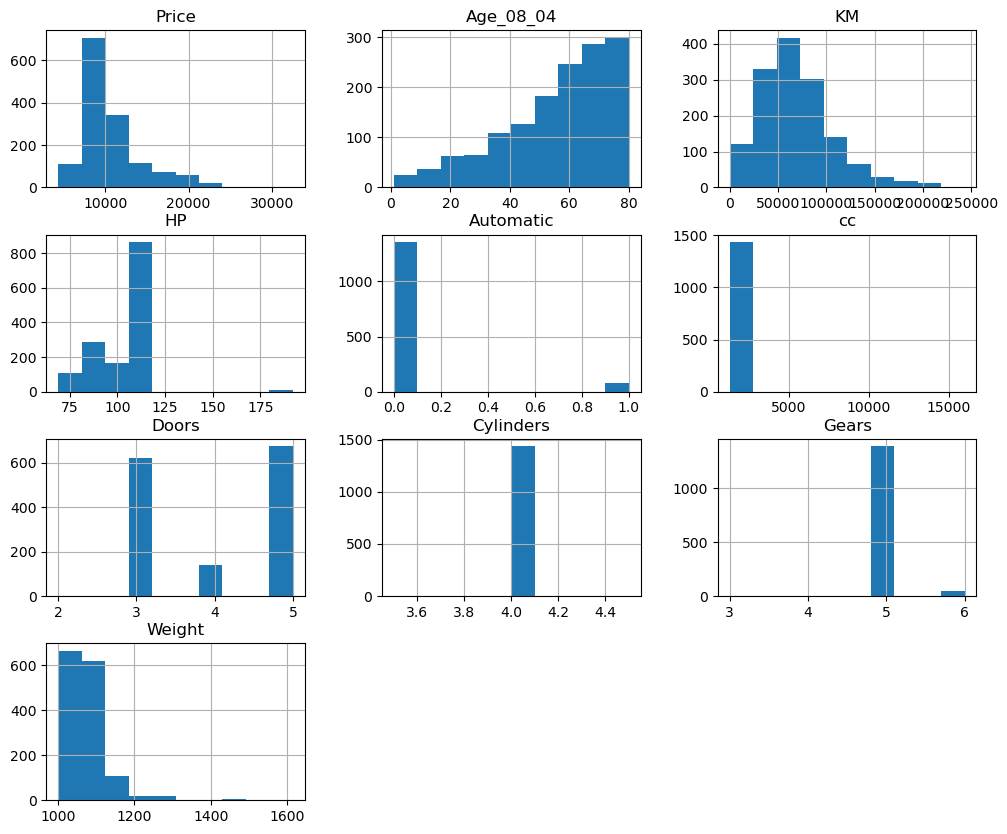

In [31]:
df.hist(figsize=(12,10))
plt.show()

In [34]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

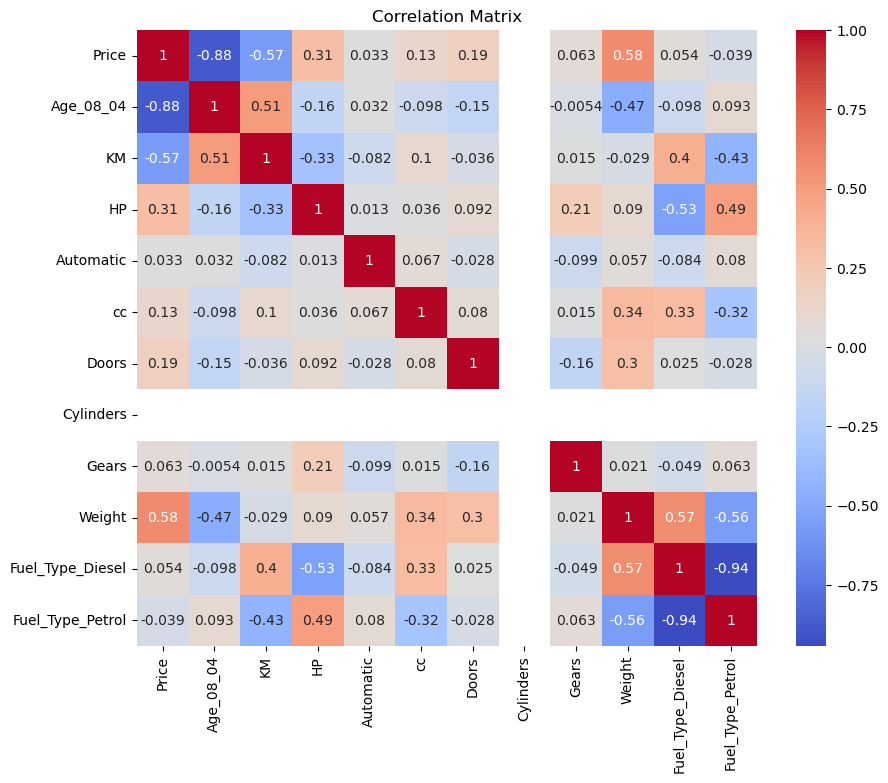

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='Age_08_04', ylabel='Price'>

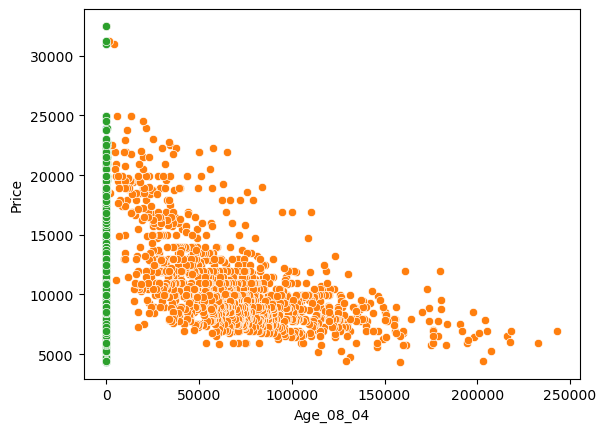

In [37]:
sns.scatterplot(x='Age_08_04', y='Price', data=df)
sns.scatterplot(x='KM', y='Price', data=df)
sns.scatterplot(x='HP', y='Price', data=df)

In [47]:
df = pd.get_dummies(df, drop_first=True)

In [48]:
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Petrol,Fuel_Type_Diesel_True
0,13500,23,46986,90,0,2000,3,4,5,1165,False,True
1,13750,23,72937,90,0,2000,3,4,5,1165,False,True
2,13950,24,41711,90,0,2000,3,4,5,1165,False,True
3,14950,26,48000,90,0,2000,3,4,5,1165,False,True
4,13750,30,38500,90,0,2000,3,4,5,1170,False,True


Q2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [52]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)   
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (1148, 11)
Testing set: (288, 11)


Q3.Build a multiple linear regression model using the training dataset.
Interpret the coefficients of the model. Build a minimum of 3 different models.

In [53]:
# Model 1 #
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

In [54]:
coeff_df = pd.DataFrame(model1.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                        Coefficient
Age_08_04             -1.208305e+02
KM                    -1.623141e-02
HP                     1.403948e+01
Automatic              1.488309e+02
cc                    -3.037219e-02
Doors                 -6.031097e+01
Cylinders             -6.536993e-13
Gears                  5.516007e+02
Weight                 2.588496e+01
Fuel_Type_Petrol       1.370809e+03
Fuel_Type_Diesel_True -6.854876e+01


In [57]:
# Model 2 #
X2 = df[['Age_08_04', 'KM', 'HP', 'Weight']]
y2 = df['Price']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

In [58]:
# Model 3 #
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_scaled, y_train)

y_pred3 = model3.predict(X_test_scaled)

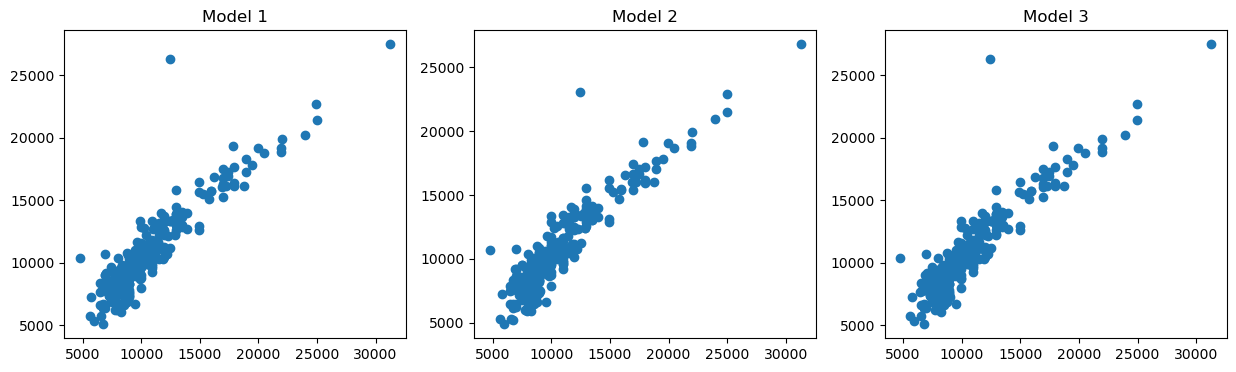

In [60]:
plt.figure(figsize=(15,4))

# Model 1
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred1)
plt.title("Model 1")

# Model 2
plt.subplot(1,3,2)
plt.scatter(y_test2, y_pred2)
plt.title("Model 2")

# Model 3
plt.subplot(1,3,3)
plt.scatter(y_test, y_pred3)
plt.title("Model 3")

plt.show()

Q4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

print("Model 1 Performance")
evaluate(y_test, y_pred1)

print("\nModel 2 Performance")
evaluate(y_test2, y_pred2)

print("\nModel 3 Performance")
evaluate(y_test, y_pred3)

Model 1 Performance
MAE: 990.8872739193926
MSE: 2203043.8231437
RMSE: 1484.2654153296505
R2 Score: 0.8348888040611084

Model 2 Performance
MAE: 1001.2017466053626
MSE: 1993321.012973071
RMSE: 1411.85020911323
R2 Score: 0.8506068681500583

Model 3 Performance
MAE: 990.887273919397
MSE: 2203043.8231437053
RMSE: 1484.2654153296523
R2 Score: 0.834888804061108


In [ ]:
Q5.Apply Lasso and Ridge methods on the model.

In [62]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Performance")
evaluate(y_test, y_pred_ridge)

Ridge Performance
MAE: 990.8591771287421
MSE: 2200942.874523289
RMSE: 1483.557506308161
R2 Score: 0.8350462635431568


In [63]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Performance")
evaluate(y_test, y_pred_lasso)

Lasso Performance
MAE: 990.9008878664434
MSE: 2202746.653977031
RMSE: 1484.1653054754483
R2 Score: 0.8349110759541999


In [64]:
lasso_coeff = pd.Series(lasso.coef_, index=X.columns)
print(lasso_coeff)

Age_08_04               -2267.276965
KM                       -611.695307
HP                        208.462936
Automatic                  34.335278
cc                        -14.045379
Doors                     -57.291081
Cylinders                   0.000000
Gears                     109.264055
Weight                   1316.411481
Fuel_Type_Petrol          457.984099
Fuel_Type_Diesel_True     -21.404474
dtype: float64


Overall Assignment Conclusion 
Age, KM → negatively impact price

HP, Weight → positively impact price

Ridge reduces overfitting

Lasso helps in feature selection

Interview Questions 

Q1 .What is Normalization & Standardization and how is it helpful?
Answer: 
1. Normalization (Min-Max Scaling)

Definition:
Normalization rescales the values of a feature to a specific range, usually 0 to 1.

Formula:
X_{\text{normalized}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}

Example:
If a column has values [10, 20, 30]:

X_{\text{normalized}} = \frac{X - 10}{30-10} = [0, 0.5, 1]

When to use:
• When features have different ranges.
• Especially useful for algorithms like K-Nearest Neighbors (KNN), Neural Networks, and Gradient Descent-based models.

2. Standardization (Z-score Scaling)

Definition:
Standardization transforms data to have mean = 0 and standard deviation = 1.

Formula:
X_{\text{standardized}} = \frac{X - \mu}{\sigma}
Where \mu is the mean, \sigma is the standard deviation.

Example:
If a column has values [10, 20, 30]:
• Mean, \mu = 20
• Std dev, \sigma \approx 8.16
• Standardized values: [-1.22, 0, 1.22]

When to use:
• When data has outliers (less sensitive than normalization).
• Useful for SVM, Logistic Regression, PCA, and other algorithms assuming normally distributed data.

Why it’s helpful
1. Improves model performance: Many ML algorithms perform better if features are on a similar scale.
2. Faster convergence: Gradient descent converges faster with scaled features.
3. Avoids dominance: Prevents features with large ranges from dominating the model.
4. Better distance measures: Algorithms like KNN or clustering rely on distance metrics; scaling ensures fair contribution from all features.




In [ ]:
Q2 What techniques can be used to address multicollinearity in multiple linear regression?
 Answer:
1.Remove Highly Correlated Features:
    •  Check correlation matrix or Variance Inflation Factor (VIF) for each variable.
	•	Remove features with high VIF (commonly VIF > 5 or 10).
	•	This directly reduces redundancy in predictors.
2. Combine Features:
	•	If two variables are highly correlated, combine them using:
	•	Averaging
	•	Principal Component Analysis (PCA) (reduces dimensionality while keeping variance)
	•	This creates new uncorrelated components for regression.
3. Regularization Methods:
	•	Ridge Regression (L2 regularization):
	•	Adds penalty term \lambda \sum \beta_j^2 to the loss function.
	•	Shrinks coefficients of correlated variables, reducing multicollinearity effects.
	•	Lasso Regression (L1 regularization):
	•	Can shrink some coefficients to zero, effectively performing feature selection.
	•	Elastic Net: Combination of L1 and L2 penalties, useful when there are many correlated variables.

4. Centering Variables:
	•	Subtract mean from each variable (mean centering).
	•	Helps reduce multicollinearity especially when interaction terms are present.

5. Collect More Data:
	•	Sometimes multicollinearity arises because the sample size is small relative to the number of predictors.
	•	Increasing data can reduce the correlation effect.